<div style="background:linear-gradient(135deg,#083344 0%,#0e7490 55%,#06b6d4 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#a5f3fc;font-weight:700;text-transform:uppercase">Chapter 86 · Case Study · Inference</div>
  <div style="font-size:33px;font-weight:900;line-height:1.1;margin:10px 0 6px">Case Study: A Clinical Trial 🩺</div>
  <div style="font-size:15px;color:#ecfeff;max-width:760px;line-height:1.6">One randomized trial, three questions: did cholesterol fall on the drug, did it fall more than placebo, and were more patients responders? Each needs a different test, paired, two-sample, and proportion, on the same patients.</div>
  <div style="margin-top:16px;font-size:13px;color:#a5f3fc">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
CY="#0891b2"; DEEP="#0e7490"; LIGHT="#67e8f9"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
rng = np.random.default_rng(86)

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 1 · THE QUESTION & THE DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Does the new LDL-lowering drug actually work?</div>
<div style="color:#4a5578;margin-top:6px">A randomized controlled trial gave patients either the treatment or a placebo, and measured LDL cholesterol at baseline and again at 12 weeks. One trial, three questions: did LDL fall on treatment? did it fall MORE than placebo? and were more patients 'responders'?</div>
</div>

In [2]:
try:    d = pd.read_excel("../../data/ch86_clinical_trial.xlsx", sheet_name="Patients")
except FileNotFoundError: d = pd.read_excel(BASE+"ch86_clinical_trial.xlsx", sheet_name="Patients")
print("loaded:", d.shape)
d["change"]=d.ldl_before-d.ldl_after   # positive = LDL dropped
print(d.groupby("arm")[["ldl_before","ldl_after","change","responder"]].mean().round(1))

loaded: (170, 6)
           ldl_before  ldl_after  change  responder
arm                                                
placebo         170.1      159.8    10.3        0.2
treatment       170.9      142.2    28.6        0.5


The treatment arm appears to drop more (a bigger average <code>change</code>) and have more responders, but a trial proves nothing until each claim is tested against the right null. The randomized design lets us attribute differences to the drug.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 2 · THREE QUESTIONS, THREE TESTS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Match each question to its design</div>
<div style="color:#4a5578;margin-top:6px">Q1 is PAIRED (same patient, before vs after) -> paired t-test. Q2 compares the CHANGE between two independent arms -> two-sample (Welch) t-test. Q3 compares a RESPONDER RATE (yes/no) between arms -> two-proportion z-test. The trial answers all three.</div>
</div>

In [3]:
print("Q1 within treatment, before vs after  -> PAIRED t-test")
print("   H0: mean LDL unchanged       H1: LDL decreased")
print("Q2 LDL change, treatment vs placebo    -> TWO-SAMPLE (Welch) t-test")
print("   H0: equal change             H1: treatment change is larger")
print("Q3 responder rate, treatment vs placebo-> TWO-PROPORTION z-test")
print("   H0: pT = pP                  H1: pT > pP")

Q1 within treatment, before vs after  -> PAIRED t-test
   H0: mean LDL unchanged       H1: LDL decreased
Q2 LDL change, treatment vs placebo    -> TWO-SAMPLE (Welch) t-test
   H0: equal change             H1: treatment change is larger
Q3 responder rate, treatment vs placebo-> TWO-PROPORTION z-test
   H0: pT = pP                  H1: pT > pP


Notice all three use the same patients but different structure. Treating the paired before/after as two independent samples (a common error) would waste the design and weaken Q1.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 3 · RUN THE ANALYSIS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">All three tests, with effect sizes and intervals</div>
<div style="color:#4a5578;margin-top:6px">We run each test, report an effect size and a confidence interval, and visualize the LDL change by arm and the responder rates.</div>
</div>

In [4]:
tr=d[d.arm=="treatment"]; pl=d[d.arm=="placebo"]
# Q1 paired
q1=stats.ttest_rel(tr.ldl_after, tr.ldl_before)
print(f"Q1 PAIRED (treatment): mean drop = {tr.change.mean():.1f} mg/dL, t={q1.statistic:.2f}, p={q1.pvalue:.2e}")
# Q2 two-sample on the change
q2=stats.ttest_ind(tr.change, pl.change, equal_var=False)
dlo,dhi=stats.t.interval(0.95, len(tr)+len(pl)-2, tr.change.mean()-pl.change.mean(),
   np.sqrt(tr.change.var(ddof=1)/len(tr)+pl.change.var(ddof=1)/len(pl)))
print(f"Q2 TWO-ARM: treat drop {tr.change.mean():.1f} vs placebo {pl.change.mean():.1f}; extra = {tr.change.mean()-pl.change.mean():.1f} mg/dL")
print(f"   Welch t={q2.statistic:.2f}, p={q2.pvalue:.2e}, 95% CI for extra drop [{dlo:.1f}, {dhi:.1f}]")

Q1 PAIRED (treatment): mean drop = 28.6 mg/dL, t=-19.65, p=9.42e-34
Q2 TWO-ARM: treat drop 28.6 vs placebo 10.3; extra = 18.3 mg/dL
   Welch t=8.45, p=1.45e-14, 95% CI for extra drop [14.0, 22.6]


Q3 RESPONDERS: treatment 52.3% vs placebo 17.1%; z=4.80, one-sided p=7.98e-07
   95% CI for the gap: [+22.0, +48.4] pts


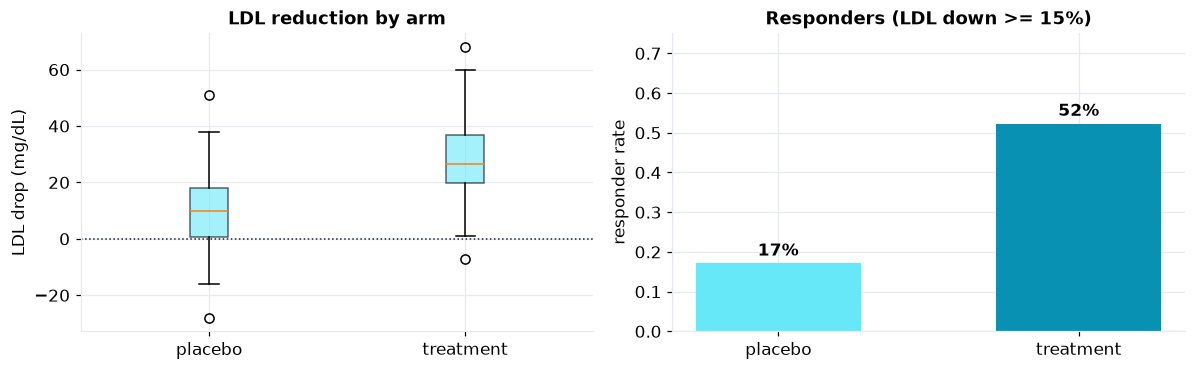

In [5]:
# Q3 two-proportion responder rate
sT,nT=tr.responder.sum(),len(tr); sP,nP=pl.responder.sum(),len(pl)
pT,pP=sT/nT,sP/nP; pool=(sT+sP)/(nT+nP)
z=(pT-pP)/np.sqrt(pool*(1-pool)*(1/nT+1/nP)); pz=1-stats.norm.cdf(z)
se=np.sqrt(pT*(1-pT)/nT+pP*(1-pP)/nP)
print(f"Q3 RESPONDERS: treatment {pT:.1%} vs placebo {pP:.1%}; z={z:.2f}, one-sided p={pz:.2e}")
print(f"   95% CI for the gap: [{(pT-pP-1.96*se)*100:+.1f}, {(pT-pP+1.96*se)*100:+.1f}] pts")
fig,ax=plt.subplots(1,2,figsize=(11,3.5))
ax[0].boxplot([pl.change.values, tr.change.values], tick_labels=["placebo","treatment"], patch_artist=True,
   boxprops=dict(facecolor=LIGHT,alpha=0.6))
ax[0].axhline(0,color=INK,lw=1,ls=":"); ax[0].set_ylabel("LDL drop (mg/dL)"); ax[0].set_title("LDL reduction by arm")
ax[1].bar(["placebo","treatment"],[pP,pT],color=[LIGHT,CY],width=0.55)
for i,v in enumerate([pP,pT]): ax[1].text(i,v+0.02,f"{v:.0%}",ha="center",fontweight="bold")
ax[1].set_ylim(0,0.75); ax[1].set_ylabel("responder rate"); ax[1].set_title("Responders (LDL down >= 15%)")
plt.tight_layout(); plt.show()

All three answers point the same way. LDL fell about <strong>29 mg/dL</strong> on treatment (paired t, p tiny). That drop is about <strong>18 mg/dL larger</strong> than placebo&#39;s (two-sample p &#8776; 10&#8315;&#185;&#8308;), so it is the drug, not regression-to-the-mean or trial effects. And the responder rate is <strong>52%</strong> on treatment versus <strong>17%</strong> on placebo (z &#8776; 4.8). The placebo arm&#39;s own ~10 mg/dL drop is exactly why a controlled comparison matters: without it, the full 29 mg/dL would look like the drug&#39;s effect.

<div style="background:#ffffff;border:1px solid #cffafe;border-left:5px solid #0e7490;border-radius:12px;padding:18px 22px;font-family:Inter,sans-serif">
<div style="font-size:12px;font-weight:800;color:#0e7490;letter-spacing:1px">📋 STATISTICIAN’S REPORT</div>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin:4px 0 8px">Conclusion: the treatment works, on all three measures</div>
<div style="color:#3f4a63;line-height:1.75"><strong>What we found.</strong> Patients on the <strong>treatment</strong> lowered their LDL cholesterol by about <strong>29 mg/dL</strong> over 12 weeks. Crucially, that is roughly <strong>18 mg/dL more</strong> than patients on placebo dropped on their own, the part we can credit to the drug. And <strong>52%</strong> of treated patients were 'responders' (a 15%+ LDL reduction) versus only <strong>17%</strong> on placebo. <br><br><strong>How confident are we?</strong> Extremely. Every comparison is far beyond the usual threshold for chance (p-values from one-in-a-million to far smaller). The 95% range for the drug&#39;s extra benefit is about <strong>14 to 22 mg/dL</strong>, a clinically meaningful reduction even at the low end. <br><br><strong>Why the placebo arm mattered.</strong> Placebo patients also improved by ~10 mg/dL (diet changes, measurement timing, the act of being in a trial). Comparing only before-vs-after on treatment would have over-credited the drug by that amount, the controlled, randomized comparison is what isolates the true effect. <br><br><strong>Caveats.</strong> This is a 12-week surrogate marker (LDL), not long-term cardiovascular outcomes; safety, durability, and side effects are separate questions a full trial program must answer.</div>
</div>

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>